<a href="https://colab.research.google.com/github/Feden-Duliente/Artificial-Intelligence---Diagnostic-Imaging-AI-Pneumonia-/blob/main/Pneumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 0:** Import necessary packages and libraries

In [28]:
import os
import shutil
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.models import Sequential
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing import image
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

Pnemonia Dataset

In [26]:
# mount the drive to access the dataset
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# create validation set from train dataset

base_dir = "/content/drive/MyDrive/DataSmart/dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

labels = ["PNEUMONIA", "NORMAL"]
split_size = 0.2 # 20% validation

for label in labels:
  # force to make a folder in the directory
  os.makedirs(os.path.join(val_dir, label), exist_ok=True)

  src = os.path.join(train_dir, label)
  dst = os.path.join(val_dir, label)

  files = os.listdir(src)
  random.shuffle(files)

  split = int(len(files) * split_size)
  val_files = files[:split]

  for file in val_files:
    shutil.copy(
        os.path.join(src, file),
        os.path.join(dst, file)
    )
print("Validation folder created!")

KeyboardInterrupt: 

In [ ]:
labels = ["PNEUMONIA", "NORMAL"]
image_resize = 150

def get_data(data_dir):
  data = []
  for label in labels:
    path = os.path.join(data_dir, label)
    class_num = labels.index(label)

    for img in os.listdir(path):
      try:
        if img.endswith('jpeg'):
          img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
          resized_arr = cv2.resize(img_arr, (image_resize, image_resize))
          data.append([resized_arr, class_num])
      except Exception as e:
        print(e)

  return np.array(data, dtype="object")

  # print(path)

In [ ]:
train = get_data('/content/drive/MyDrive/DataSmart/dataset/train')
test = get_data('/content/drive/MyDrive/DataSmart/dataset/test')
val = get_data('/content/drive/MyDrive/DataSmart/dataset/val')

**Data Visualization and Preprocessing**

<Axes: xlabel='count'>

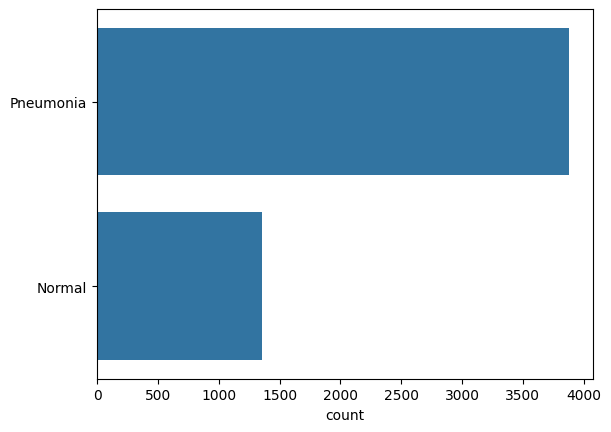

In [ ]:
l = []
for i in train:
  if (i[1] == 0):
    l.append("Pneumonia")
  else:
    l.append("Normal")
sns.countplot(l)

Text(0.5, 1.0, 'NORMAL')

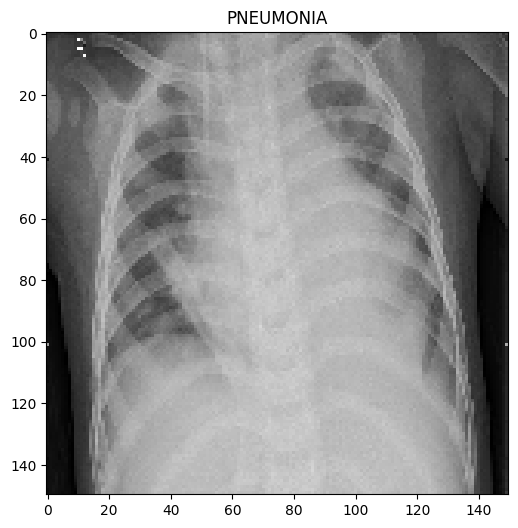

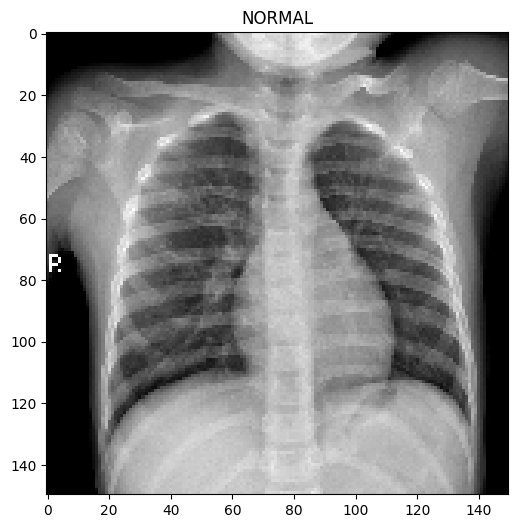

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6, 6))

plt.imshow(train[-1][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [ ]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feat, label in train:
  x_train.append(feat)
  y_train.append(label)

for feat, label in val:
  x_val.append(feat)
  y_val.append(label)

for feat, label in test:
  x_test.append(feat)
  y_test.append(label)

In [ ]:
# Normalize the data

x_train = np.array(x_train)/255
x_val = np.array(x_val)/255
x_test = np.array(x_test)/255

In [ ]:
x_train = x_train.reshape(-1, image_resize, image_resize, 1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1, image_resize, image_resize, 1)
y_val = np.array(y_val)

x_test = x_test.reshape(-1, image_resize, image_resize, 1)
y_test = np.array(y_test)

In [ ]:
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

**Training the model**

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), strides=1, padding='same', activation="relu", input_shape=(150, 150, 1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2), strides=2, padding='same'))
model.add(Conv2D(64, (3, 3), strides=1, padding='same', activation="relu"))
model.add(Dropout(0.1))

model.add(BatchNormalization())
model.add(MaxPool2D((2,2), strides=2, padding="same"))
model.add(Conv2D(64, (3, 3), strides=1, padding='same', activation="relu"))

model.add(BatchNormalization())
model.add(MaxPool2D((2,2), strides=2, padding="same"))
model.add(Conv2D(128, (3, 3), strides=1, padding='same', activation="relu"))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2), strides=2, padding="same"))

model.add(BatchNormalization())
model.add(MaxPool2D((2,2), strides=2, padding="same"))
model.add(Conv2D(256, (3, 3), strides=1, padding='same', activation="relu"))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2), strides=2, padding="same"))

model.add(Flatten())
model.add(Dense(units=128, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation="sigmoid"))

model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,04

 Total params: 722,625 (2.76 MB)

 Trainable params: 721,281 (2.75 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    verbose=1,
    factor=0.3,
    min_lr=0.000001
)

In [ ]:
from sklearn.utils import validation
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=12,
    validation_data=datagen.flow(
        x_val,
        y_val
        ),
    callbacks=[learning_rate_reduction]
)

Epoch 1/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 32s 114ms/step - accuracy: 0.9042 - loss: 0.2942 - val_accuracy: 0.7834 - val_loss: 5.7549 - learning_rate: 0.0010
Epoch 2/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9580 - loss: 0.1187 - val_accuracy: 0.7834 - val_loss: 11.4176 - learning_rate: 0.0010
Epoch 3/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9695 - loss: 0.0925 - val_accuracy: 0.7866 - val_loss: 4.8706 - learning_rate: 0.0010
Epoch 4/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9803 - loss: 0.0579 - val_accuracy: 0.7954 - val_loss: 3.4742 - learning_rate: 0.0010
Epoch 5/12
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9805 - loss: 0.0537 - val_accuracy: 0.7930 - val_loss: 3.3676 - learning_rate: 0.0010
Epoch 6/12
163/164 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9842 - loss: 0.0409
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9824 - loss: 

In [ ]:
model.evaluate(x_test, y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7260 - loss: 3.7565


[3.7565338611602783, 0.7259615659713745]

In [ ]:
print(f"Loss of the model is {model.evaluate(x_test, y_test)[0]}")
print(f"Accuracy of the model is {model.evaluate(x_test, y_test)[1]*100}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7260 - loss: 3.7565
Loss of the model is 3.7565338611602783
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7260 - loss: 3.7565
Accuracy of the model is 72.59615659713745%


**Analyze Model Performance**

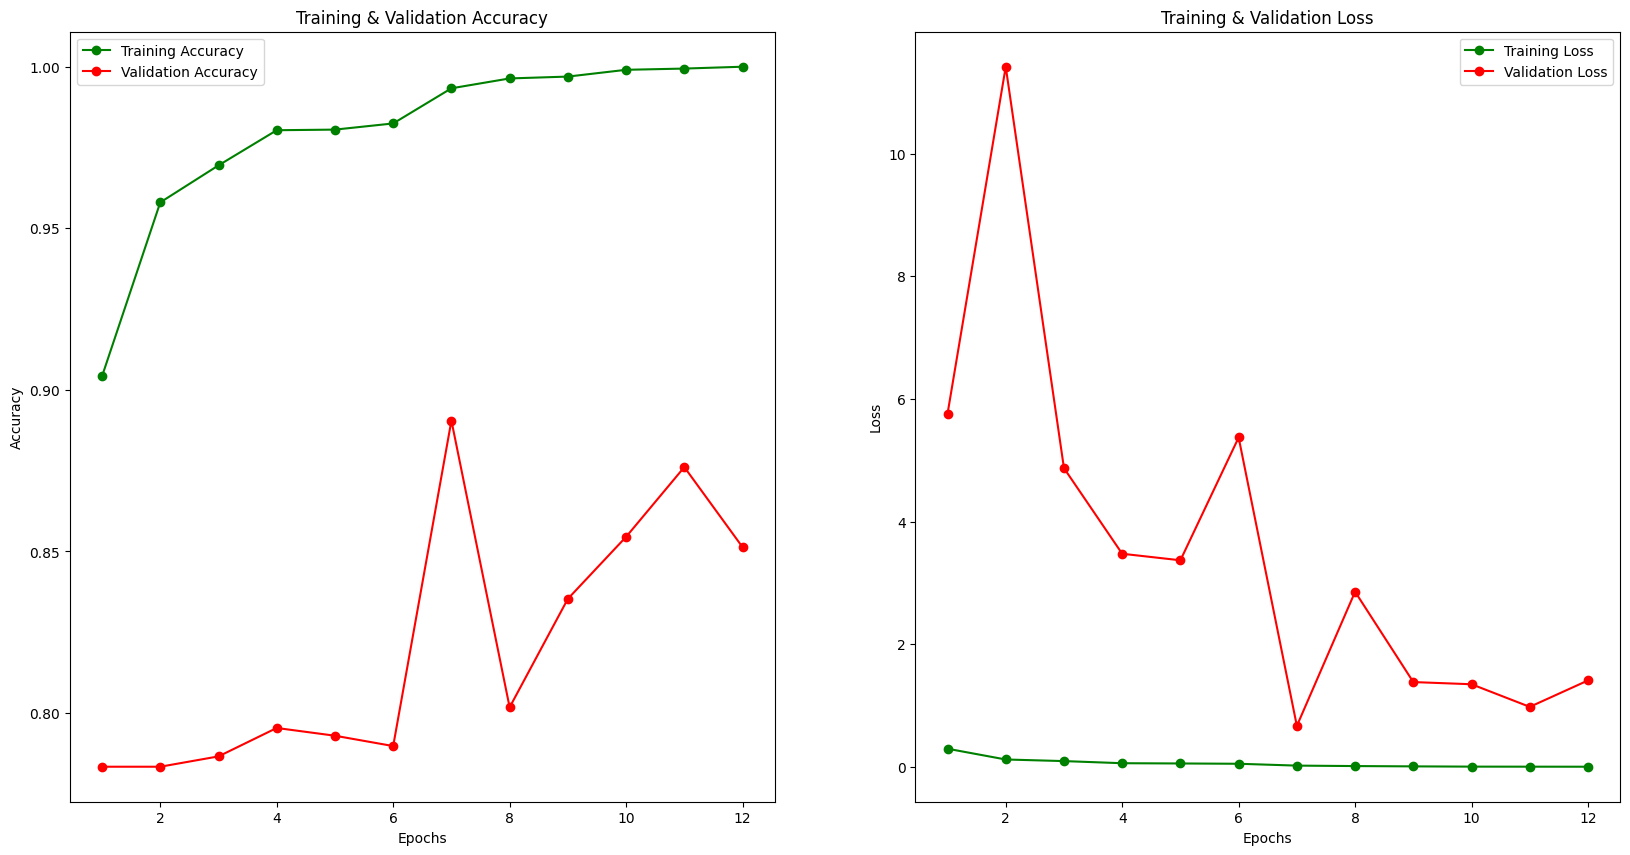

In [ ]:

fig, ax = plt.subplots(1, 2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc)+1)

fig.set_size_inches(20, 10)

ax[0].plot(epochs, train_acc, 'go-', label="Training Accuracy")
ax[0].plot(epochs, val_acc, 'ro-', label="Validation Accuracy")
ax[0].set_title(label="Training & Validation Accuracy")
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')

ax[1].plot(epochs, train_loss, 'g-o', label="Training Loss")
ax[1].plot(epochs, val_loss, 'r-o', label="Validation Loss")
ax[1].set_title(label="Training & Validation Loss")
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')

plt.show()

In [ ]:
predictions = (model.predict(x_test) > 0.5).astype("int32")
predictions = predictions.reshape(1, -1)[0]
predictions[:15]

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [ ]:
print(classification_report(y_test, predictions, target_names=["Pneumonia (Class 0)", 'Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.70      1.00      0.82       390
   Normal (Class 1)       0.98      0.27      0.43       234

           accuracy                           0.73       624
          macro avg       0.84      0.64      0.62       624
       weighted avg       0.80      0.73      0.67       624



In [ ]:
cm = confusion_matrix(y_test, predictions)

In [ ]:
cm

array([[389,   1],
       [170,  64]])

In [ ]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

**Some Correctly Predicted Classes**

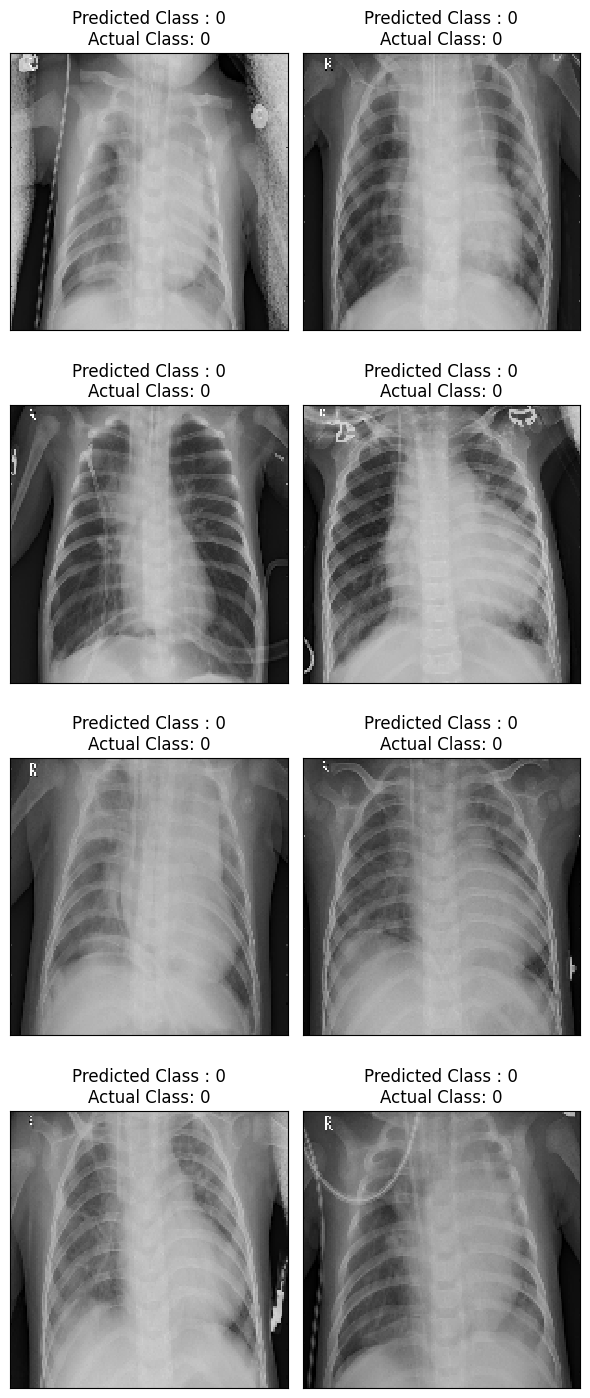

In [ ]:
i = 0
plt.figure(figsize=(6, 15))
for c in correct[10:18]:
  plt.subplot(4, 2, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150, 150), cmap="gray", interpolation="none")
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class: {y_test[c]}")
  plt.tight_layout()
  i += 1

**Some Incorrectly predicted Classes**

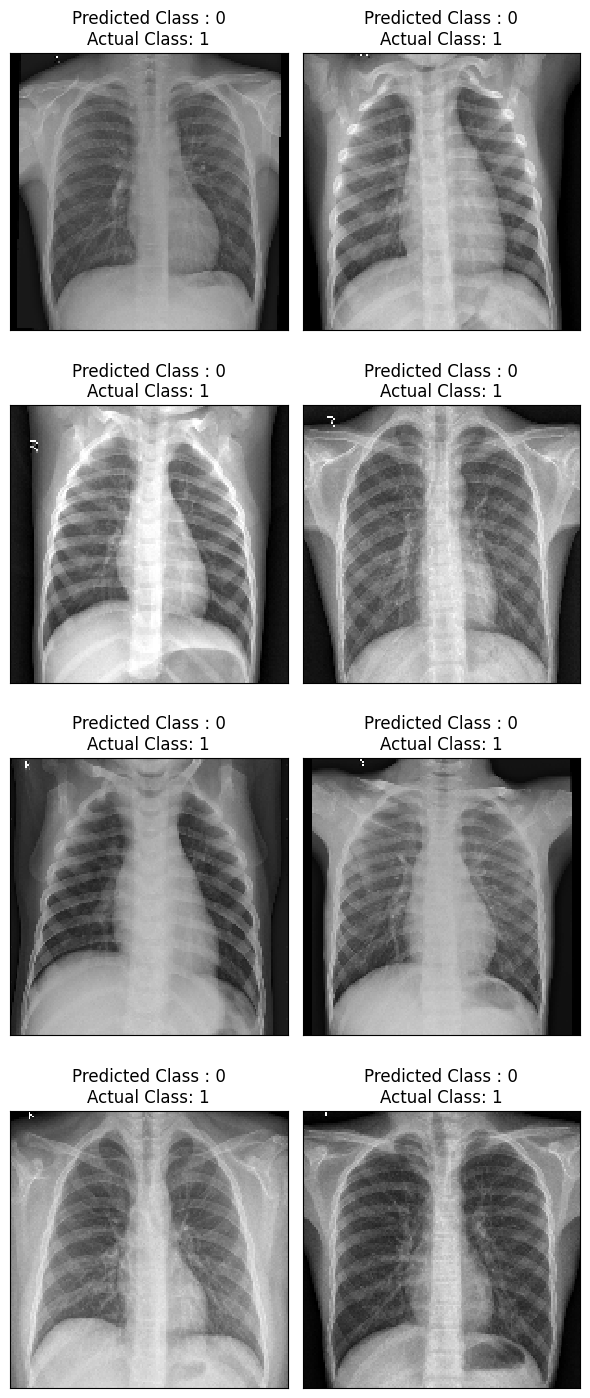

In [ ]:
i = 0
plt.figure(figsize=(6, 15))
for c in incorrect[10:18]:
  plt.subplot(4, 2, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150, 150), cmap="gray", interpolation="none")
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class: {y_test[c]}")
  plt.tight_layout()
  i += 1

**Test the model through image upload**

In [50]:
# open file picker
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

Saving person1_virus_13.jpeg to person1_virus_13 (2).jpeg


In [52]:
# load grayscale like the model input
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# resize to 150 x 150
img = cv2.resize(img, (150, 150))

# normalize
img = img.astype('float32') / 255.0

# reshape to match model input
img = img.reshape(1, 150, 150, 1)

In [53]:
# prediction
prediction = model.predict(img)

# 0 - PNEUMONIA, 1 - NORMAL
if prediction[0][0] > 0.5:
  result = "NORMAL"
else:
  result = 'PNEUMONIA'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


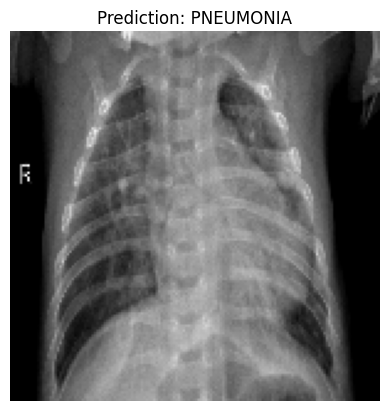

In [54]:
# show image
plt.imshow(img.reshape(150, 150), cmap="gray")
plt.title(f"Prediction: {result}")
plt.axis("off")
plt.show()